<a href="https://colab.research.google.com/github/Shivanij2604/Clinical-Trial-Disease-Category-Classification-Using-NLP-and-Machine-Learning/blob/main/PROJECT5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Project Title: Clinical Trial Disease Category Classification Using NLP and Machine Learning


### 📌 Project Overview

Clinical trials generate large volumes of unstructured medical text containing information about diseases, treatments, patient eligibility, and study objectives. Manually categorizing these clinical trial summaries into disease categories can be time-consuming and error-prone.

This project develops a Natural Language Processing (NLP) and Machine Learning based system that automatically classifies clinical trial summaries into their corresponding disease categories.

### 🎯 Objective

* Analyze clinical trial text data
* Perform text preprocessing and feature engineering
* Explore disease-wise patterns through EDA
* Build and compare multiple machine learning models
* Predict disease categories from clinical trial summaries
* Identify the best-performing classification model

### 📊 Disease Categories

* Breast Cancer
* Type 2 Diabetes
* COVID-19
* Anxiety
* Chronic Obstructive Pulmonary Disease (COPD)
* Rheumatoid Arthritis
* Glaucoma
* Sickle Cell Anemia

### 🛠️ Technologies Used

* Python
* Pandas
* NumPy
* Scikit-learn
* NLP
* TF-IDF Vectorization
* Matplotlib
* Seaborn

### 🤖 Machine Learning Models

* Naive Bayes
* Logistic Regression
* Random Forest
* AdaBoost
* XGBoost
* Support Vector Machine (LinearSVC)



In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import joblib

In [44]:
import re
import nltk
from nltk.tokenize import word_tokenize # split the text into words
from nltk.corpus import stopwords # remove the stopwords like a, an, the
from nltk.stem import WordNetLemmatizer # to lemmatize the words to their root form
from sklearn.feature_extraction.text import TfidfVectorizer # to convert words to numbers

In [45]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [46]:
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from collections import Counter

In [47]:
#  Load CSV into DataFrame
df = pd.read_csv("clinical_trials_raw_patient2trial_conditions.csv",encoding='latin1')
print('Dataset Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (60337, 16)

Column Names:
['source_condition_query', 'nct_id', 'title', 'official_title', 'brief_summary', 'conditions', 'interventions', 'overall_status', 'study_type', 'phase', 'sex', 'minimum_age', 'maximum_age', 'healthy_volunteers', 'eligibility_criteria', 'clinicaltrials_url']

First 5 rows:


,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
0,breast cancer,NCT03676114,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114
1,breast cancer,NCT02941614,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614
2,breast cancer,NCT04509063,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,NaN,FEMALE,44 Years,49 Years,True,Inclusion Criteria:\n\n* Residence: Central De...,https://clinicaltrials.gov/study/NCT04509063
3,breast cancer,NCT04327063,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,18 Years,85 Years,False,Inclusion Criteria:\n\n1. Women with non-metas...,https://clinicaltrials.gov/study/NCT04327063
4,breast cancer,NCT06778863,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,18 Years,NaN,False,Key Inclusion Criteria:\n\n* Patients must be ...,https://clinicaltrials.gov/study/NCT06778863


In [48]:
# Basic Dataset Info
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Disease Category Distribution ===')
print(df['source_condition_query'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60337 entries, 0 to 60336
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   source_condition_query  60337 non-null  object
 1   nct_id                  60337 non-null  object
 2   title                   60337 non-null  object
 3   official_title          59551 non-null  object
 4   brief_summary           60337 non-null  object
 5   conditions              60336 non-null  object
 6   interventions           54276 non-null  object
 7   overall_status          60337 non-null  object
 8   study_type              60337 non-null  object
 9   phase                   23336 non-null  object
 10  sex                     60304 non-null  object
 11  minimum_age             57121 non-null  object
 12  maximum_age             28400 non-null  object
 13  healthy_volunteers      58857 non-null  object
 14  eligibility_criteria    60326 non

In [49]:
print('\n=== Missing Values Summary ===')

missing_df = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage (%)': ((df.isnull().sum() / len(df)) * 100).round(2)
})

print(missing_df)


=== Missing Values Summary ===
                        Missing_Count  Missing_Percentage (%)
source_condition_query              0                    0.00
nct_id                              0                    0.00
title                               0                    0.00
official_title                    786                    1.30
brief_summary                       0                    0.00
conditions                          1                    0.00
interventions                    6061                   10.05
overall_status                      0                    0.00
study_type                          0                    0.00
phase                           37001                   61.32
sex                                33                    0.05
minimum_age                      3216                    5.33
maximum_age                     31937                   52.93
healthy_volunteers               1480                    2.45
eligibility_criteria               11 

In [50]:
df.describe(include='all')

,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
count,60337,60337,60337,59551,60337,60336,54276,60337,60337,23336,60304,57121,28400,58857,60326,60337
unique,8,60337,60191,59272,60064,26460,46807,13,3,7,3,142,182,2,59872,60337
top,breast cancer,NCT06158945,COVID-19 Antibody Responses In Cystic Fibrosis,ACTIV-6: COVID-19 Outpatient Randomized Trial ...,Investigators are building an empirical eviden...,Breast Cancer,No intervention,COMPLETED,INTERVENTIONAL,PHASE2,ALL,18 Years,75 Years,False,No eligibility criteria,https://clinicaltrials.gov/study/NCT06158945
freq,16301,1,5,8,10,5060,161,33659,45548,7408,47436,39226,4100,45860,57,1


In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df.isnull().sum().sort_values(ascending=False)

,0
phase,37001
maximum_age,31937
interventions,6061
minimum_age,3216
healthy_volunteers,1480
official_title,786
sex,33
eligibility_criteria,11
conditions,1
overall_status,0


In [53]:
df.columns

Index(['source_condition_query', 'nct_id', 'title', 'official_title',
       'brief_summary', 'conditions', 'interventions', 'overall_status',
       'study_type', 'phase', 'sex', 'minimum_age', 'maximum_age',
       'healthy_volunteers', 'eligibility_criteria', 'clinicaltrials_url'],
      dtype='object')

In [54]:
df_copy=df.copy()

In [55]:
df['sex'].mode()

,sex
0,ALL


In [56]:
drop_cols = [
    'nct_id',
    'clinicaltrials_url',
    'minimum_age',
    'maximum_age'
]

df.drop(columns=drop_cols, inplace=True)

In [57]:
df['interventions'] = df.groupby('source_condition_query')['interventions'].ffill()

In [58]:
df.dropna(subset=['official_title', 'brief_summary','conditions','eligibility_criteria'], inplace=True)

In [59]:
df['phase']=df['phase'].fillna(df['phase'].mode()[0])
df['healthy_volunteers']=df['healthy_volunteers'].fillna(df['healthy_volunteers'].mode()[0])
df['sex']=df['sex'].fillna(df['sex'].mode()[0])

/tmp/ipykernel_38553/1884441478.py:2: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [60]:
df
df.shape

(59541, 12)

In [61]:
print("Total Rows:", len(df))
print("Unique official_title:", df['official_title'].nunique())

Total Rows: 59541
Unique official_title: 59263


In [62]:
df.columns

Index(['source_condition_query', 'title', 'official_title', 'brief_summary',
       'conditions', 'interventions', 'overall_status', 'study_type', 'phase',
       'sex', 'healthy_volunteers', 'eligibility_criteria'],
      dtype='object')

In [63]:
X=df['brief_summary']
Y=df['source_condition_query']


In [64]:
def text_cleaning(text):

    # Lower casing
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # Remove Emails
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove Hashtags
    text = re.sub(r'#\w+', ' ', text)

    # Remove Mentions
    text = re.sub(r'@\w+', ' ', text)

    # Remove Punctuations
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove extra spaces only
    text = ' '.join(text.split())

    return text

In [65]:
X

,brief_summary
0,Breast cancer patients often have perioperativ...
1,Many breast cancer patients experience psychol...
2,"Based on an American study by Scherer et al., ..."
3,Compare the effect of ropivacaine versus place...
4,Phase 1 dose escalation and expansion study of...
...,...
60332,Zinc is a nutritionally essential trace elemen...
60333,"Multi-phase, patient navigator-based program i..."
60334,Sickle cell disease (SCD) is the most common i...
60335,A promising approach for the treatment of gene...


In [66]:
text_cleaning(X[1])

'many breast cancer patients experience psychological distress during their cancer care journey there are effective treatments for breast cancer patients experiencing distress such as individual or group therapy health education and medication unfortunately clinicians may not be aware of the symptoms of distress in their breast cancer patients and some breast cancer patients who could benefit from referral to behavioral health specialists are overlooked new guidelines recommend that all cancer patients be regularly screened for distress however there are unanswered questions about the impact of distress screening conducted on a large scale few studies have evaluated the impact of distress screening on important outcomes in breast cancer patients such as patient experience and use of health care services as compared to the usual care offered by the health care organization in addition oncology clinicians may be uncertain about the benefits of large scale distress screening and pilot scr

In [67]:
df['Cleaned_text']=df['brief_summary'].apply(text_cleaning)

In [68]:
df[['brief_summary','Cleaned_text']]

,brief_summary,Cleaned_text
0,Breast cancer patients often have perioperativ...,breast cancer patients often have perioperativ...
1,Many breast cancer patients experience psychol...,many breast cancer patients experience psychol...
2,"Based on an American study by Scherer et al., ...",based on an american study by scherer et al it...
3,Compare the effect of ropivacaine versus place...,compare the effect of ropivacaine versus place...
4,Phase 1 dose escalation and expansion study of...,phase 1 dose escalation and expansion study of...
...,...,...
60332,Zinc is a nutritionally essential trace elemen...,zinc is a nutritionally essential trace elemen...
60333,"Multi-phase, patient navigator-based program i...",multi phase patient navigator based program in...
60334,Sickle cell disease (SCD) is the most common i...,sickle cell disease scd is the most common inh...
60335,A promising approach for the treatment of gene...,a promising approach for the treatment of gene...


In [69]:
#Tokenize
def WORD_tokenize(text):
  return word_tokenize(text)

In [70]:
WORD_tokenize(text_cleaning(X[0]))

['breast',
 'cancer',
 'patients',
 'often',
 'have',
 'perioperative',
 'emotional',
 'disorders',
 'such',
 'as',
 'anxiety',
 'and',
 'depression',
 'which',
 'can',
 'lead',
 'to',
 'poor',
 'quality',
 'of',
 'recovery',
 'this',
 'study',
 'aims',
 'to',
 'determine',
 'whether',
 'ketamine',
 'could',
 'improve',
 'the',
 'quality',
 'of',
 'recovery',
 'in',
 'breast',
 'cancer',
 'patients',
 'meanwhile',
 'it',
 'will',
 'show',
 'if',
 'ketamine',
 'could',
 'improve',
 'anxiety',
 'depression',
 'postoperative',
 'pain',
 'and',
 'fatigue',
 'this',
 'trial',
 'also',
 'will',
 'bring',
 'great',
 'concerns',
 'on',
 'patients',
 'mental',
 'health',
 'perioperatively',
 'and',
 'explore',
 'the',
 'measures',
 'to',
 'improve',
 'their',
 'quality',
 'of',
 'life']

In [71]:
stop_word=stopwords.words('english')
stop_word

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [72]:
def stop_word_lematization(text_list):
  lemmatizer=WordNetLemmatizer()
  return ' '.join([lemmatizer.lemmatize(word) for word in text_list if word not in stop_word])

In [73]:
X[1]

'Many breast cancer patients experience psychological distress during their cancer care journey. There are effective treatments for breast cancer patients experiencing distress, such as individual or group therapy, health education, and medication. Unfortunately, clinicians may not be aware of the symptoms of distress in their breast cancer patients, and some breast cancer patients who could benefit from referral to behavioral health specialists are overlooked. New guidelines recommend that all cancer patients be regularly screened for distress. However, there are unanswered questions about the impact of distress screening conducted on a large scale. Few studies have evaluated the impact of distress screening on important outcomes in breast cancer patients, such as patient experience and use of health care services, as compared to the usual care offered by the health care organization. In addition, oncology clinicians may be uncertain about the benefits of large-scale distress screenin

In [74]:
stop_word_lematization(WORD_tokenize(text_cleaning(X[1])))

'many breast cancer patient experience psychological distress cancer care journey effective treatment breast cancer patient experiencing distress individual group therapy health education medication unfortunately clinician may aware symptom distress breast cancer patient breast cancer patient could benefit referral behavioral health specialist overlooked new guideline recommend cancer patient regularly screened distress however unanswered question impact distress screening conducted large scale study evaluated impact distress screening important outcome breast cancer patient patient experience use health care service compared usual care offered health care organization addition oncology clinician may uncertain benefit large scale distress screening pilot screening program uniformly successful particularly community oncology setting overarching goal study assess effectiveness implementing guideline recommended distress screening program newly diagnosed breast cancer patient improving id

In [75]:
def Text_PreProcessing(text):
  text=text_cleaning(text)
  text_list=WORD_tokenize(text)
  text=stop_word_lematization(text_list)
  return text

In [76]:
df['Cleaned_text']=df['brief_summary'].apply(Text_PreProcessing)

In [77]:
df

,source_condition_query,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,healthy_volunteers,eligibility_criteria,Cleaned_text
0,breast cancer,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,False,Inclusion Criteria:\n\n1. American Society of ...,breast cancer patient often perioperative emot...
1,breast cancer,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,PHASE2,ALL,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,many breast cancer patient experience psycholo...
2,breast cancer,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,PHASE2,FEMALE,True,Inclusion Criteria:\n\n* Residence: Central De...,based american study scherer et al hypothesize...
3,breast cancer,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,False,Inclusion Criteria:\n\n1. Women with non-metas...,compare effect ropivacaine versus placebo pect...
4,breast cancer,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,False,Key Inclusion Criteria:\n\n* Patients must be ...,phase 1 dose escalation expansion study clsp 1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60332,sickle cell anemia,Zinc Supplementation in Children With Sickle C...,The Effects of Zinc Supplementation in Childre...,Zinc is a nutritionally essential trace elemen...,Sickle Cell Disease | Zinc Deficiency | Infection,Zinc Sulfate Tablets | Standard of Care,COMPLETED,INTERVENTIONAL,PHASE2,ALL,False,Inclusion Criteria:\n\n* Male or female infant...,zinc nutritionally essential trace element fou...
60333,sickle cell anemia,Enhancing Use of Hydroxyurea In Sickle Cell Di...,Enhancing Use of Hydroxyurea In Sickle Cell Di...,"Multi-phase, patient navigator-based program i...",Sickle Cell Disease,Patient Navigator | Recruitment into Specialty...,COMPLETED,INTERVENTIONAL,PHASE2,ALL,False,PHASE I:\n\nInclusion Criteria:\n\n* Patient S...,multi phase patient navigator based program ri...
60334,sickle cell anemia,Vascular Function Intervention Trial in Sickle...,Development of a Ready-to-use Nutraceutical Fo...,Sickle cell disease (SCD) is the most common i...,Sickle Cell Disease,Vascular ready-to-use supplementary food | Reg...,UNKNOWN,INTERVENTIONAL,PHASE2 | PHASE3,ALL,False,Inclusion Criteria:\n\n* Aged 8-11 years old a...,sickle cell disease scd common inherited disor...
60335,sickle cell anemia,Hematopoietic Stem Cell BCL11A Enhancer Gene E...,An Adaptive Design Basket Trial of Hematopoiet...,A promising approach for the treatment of gene...,Sickle Cell Disease | Sickle Cell Anemia (HbSS...,autologous bone marrow derived CD34+ HSPCs ele...,RECRUITING,INTERVENTIONAL,PHASE1,ALL,False,Inclusion Criteria:\n\n1. Diagnosis of either ...,promising approach treatment genetic disease c...


In [78]:
df['Cleaned_text'].iloc[0]

'breast cancer patient often perioperative emotional disorder anxiety depression lead poor quality recovery study aim determine whether ketamine could improve quality recovery breast cancer patient meanwhile show ketamine could improve anxiety depression postoperative pain fatigue trial also bring great concern patient mental health perioperatively explore measure improve quality life'

# 📊 Exploratory Data Analysis (EDA)

In [79]:
#  EDA - Step 1: Basic Statistical Summary
print("=" * 50)
print(" DATASET OVERVIEW")
print("=" * 50)
print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")
print(f"\nColumn Names  : {df.columns.tolist()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nData Types:\n{df.dtypes}")

 DATASET OVERVIEW
Total Rows    : 59541
Total Columns : 13

Column Names  : ['source_condition_query', 'title', 'official_title', 'brief_summary', 'conditions', 'interventions', 'overall_status', 'study_type', 'phase', 'sex', 'healthy_volunteers', 'eligibility_criteria', 'Cleaned_text']

Missing Values:
source_condition_query    0
title                     0
official_title            0
brief_summary             0
conditions                0
interventions             0
overall_status            0
study_type                0
phase                     0
sex                       0
healthy_volunteers        0
eligibility_criteria      0
Cleaned_text              0
dtype: int64

Data Types:
source_condition_query    object
title                     object
official_title            object
brief_summary             object
conditions                object
interventions             object
overall_status            object
study_type                object
phase                     object
sex     

In [80]:
#  EDA - Step 2: Disease Category Distribution
category_counts = df['source_condition_query'].value_counts().reset_index()
category_counts.columns = ['Disease Category', 'Count']

print("Disease Category Distribution:")
print(category_counts)

fig = px.bar(
    category_counts,
    x='Disease Category',
    y='Count',
    color='Disease Category',
    title=' Disease Category Distribution',
    text='Count'
)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False, xaxis_tickangle=-30)
fig.show()

Disease Category Distribution:
                        Disease Category  Count
0                          breast cancer  16159
1                        type 2 diabetes  11256
2                               covid-19  10151
3                                anxiety   9202
4  chronic obstructive pulmonary disease   6065
5                   rheumatoid arthritis   3585
6                               glaucoma   2008
7                     sickle cell anemia   1115


In [107]:
#  EDA - Step 3: Pie Chart - Category Proportion
fig = px.pie(
    category_counts,
    names='Disease Category',
    values='Count',
    title='Disease Category Proportion',
    hole=0.3
)
fig.show()

In [108]:
# EDA - Step 4: Text Length Analysis
df['text_length'] = df['brief_summary'].astype(str).apply(len)
df['word_count']  = df['brief_summary'].astype(str).apply(lambda x: len(x.split()))

print("📝 Text Length Stats:")
print(df[['text_length', 'word_count']].describe())

fig = px.box(
    df,
    x='source_condition_query',
    y='word_count',
    color='source_condition_query',
    title='Word Count per Disease Category'
)
fig.update_layout(showlegend=False, xaxis_tickangle=-30)
fig.show()

📝 Text Length Stats:
        text_length    word_count
count  59541.000000  59541.000000
mean     690.620094    102.223543
std      630.944598     93.769084
min       17.000000      2.000000
25%      254.000000     37.000000
50%      469.000000     69.000000
75%      907.000000    134.000000
max     5012.000000    799.000000


In [83]:
# EDA - Step 5: Most Common Medical Keywords
stop_words = set(stopwords.words('english'))

all_words = []
for text in df['brief_summary'].astype(str):
    tokens = text.lower().split()
    tokens = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 3]
    all_words.extend(tokens)

word_freq = Counter(all_words).most_common(20)
word_df = pd.DataFrame(word_freq, columns=['Word', 'Frequency'])

fig = px.bar(
    word_df,
    x='Frequency',
    y='Word',
    orientation='h',
    color='Frequency',
    color_continuous_scale='Blues',
    title='🔤 Top 20 Most Common Medical Keywords'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

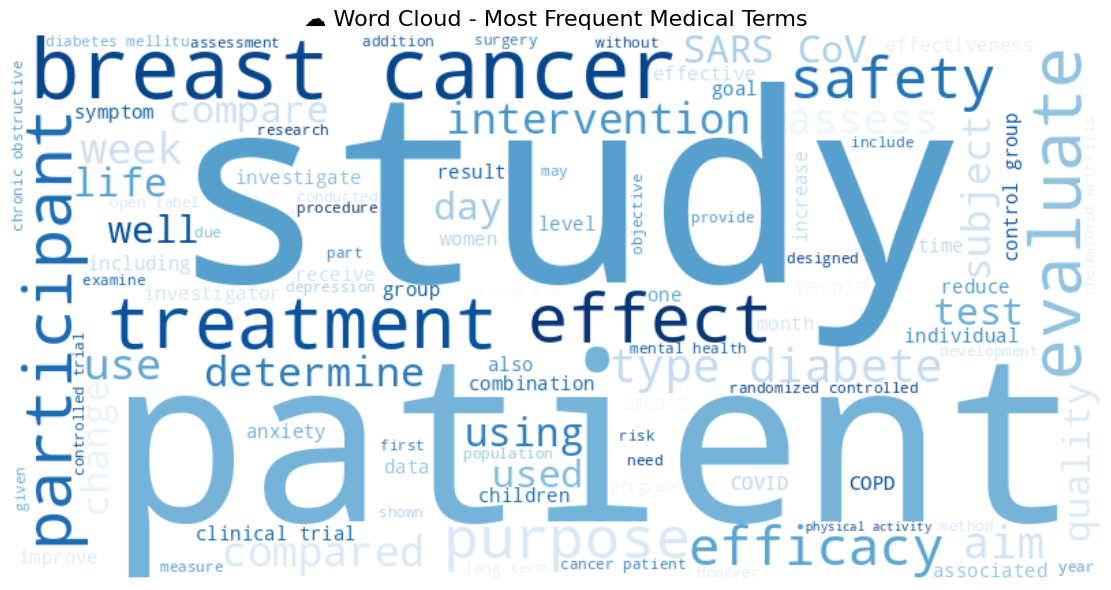

In [84]:
# EDA - Step 6: Word Cloud
from wordcloud import WordCloud

text_all = ' '.join(df['brief_summary'].astype(str).tolist())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stop_words,
    colormap='Blues',
    max_words=100
).generate(text_all)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('☁️ Word Cloud - Most Frequent Medical Terms', fontsize=16)
plt.tight_layout()
plt.show()

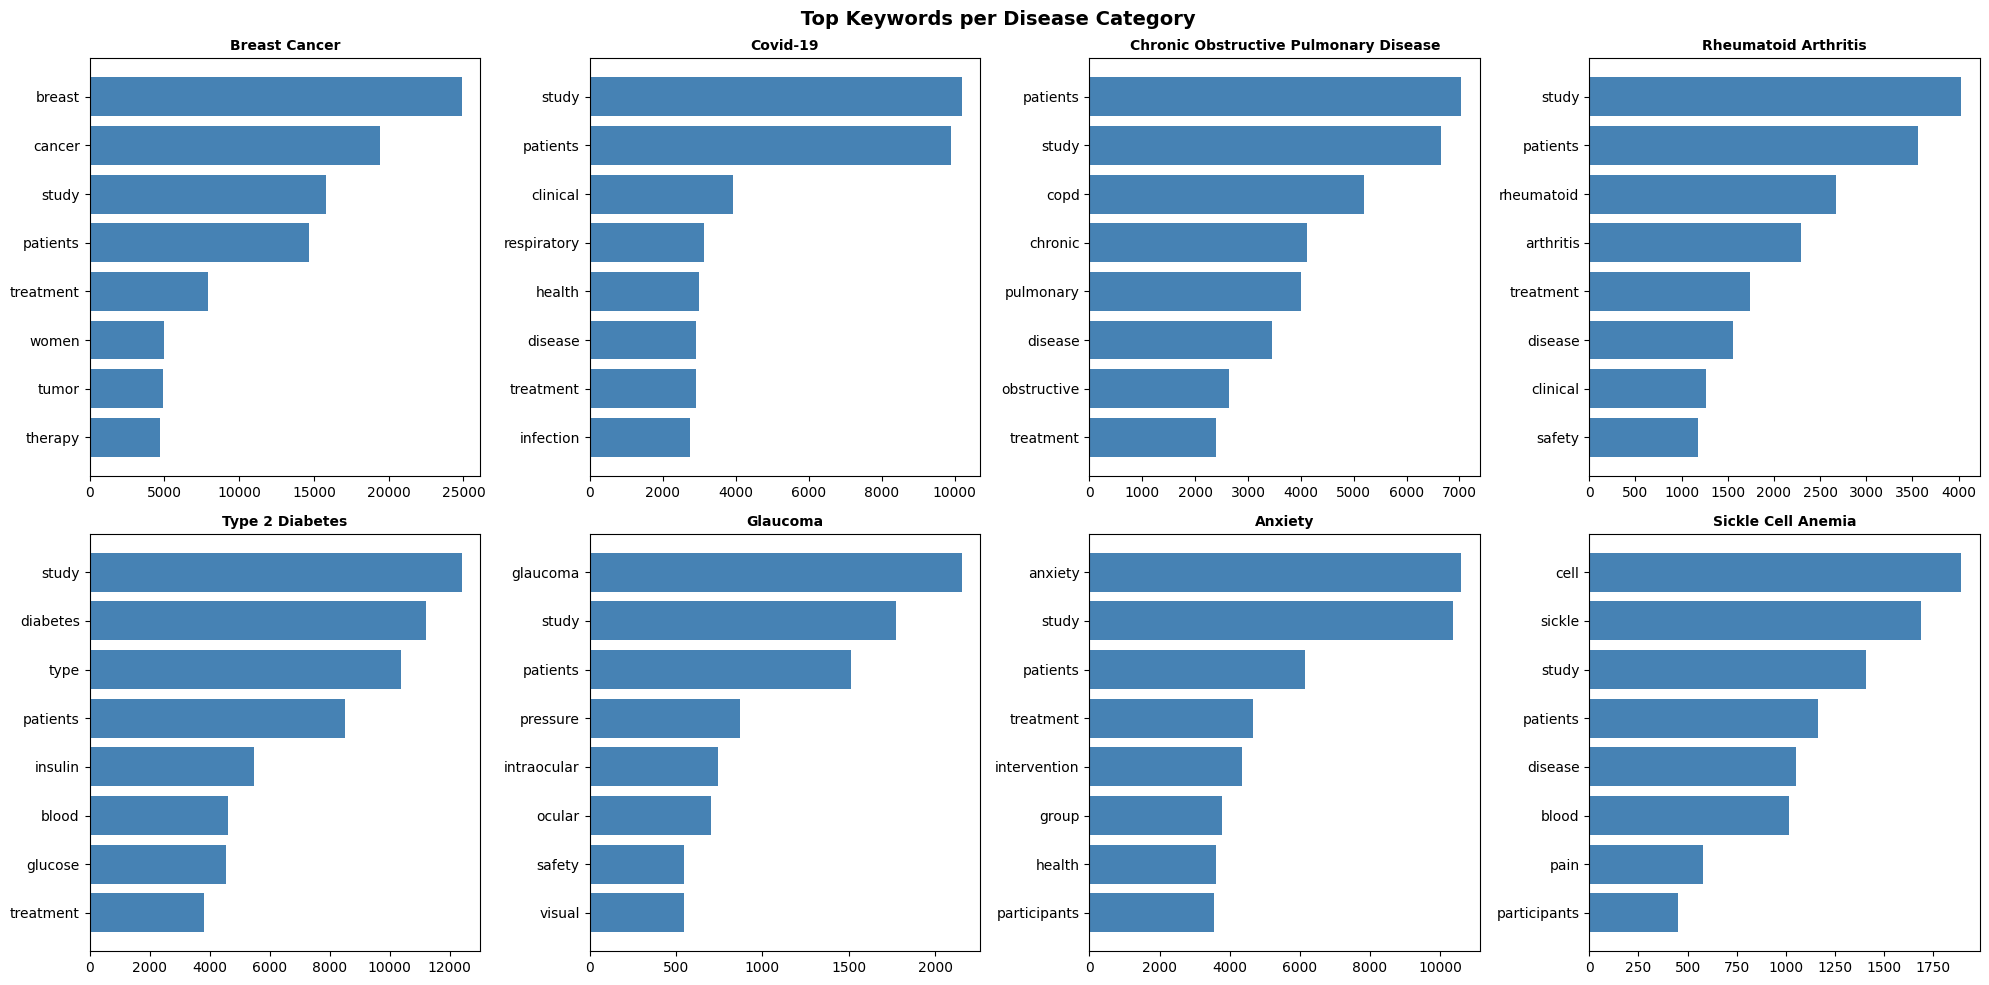

In [85]:
#  EDA - Step 7: Top Keywords per Disease Category
diseases = df['source_condition_query'].unique()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, disease in enumerate(diseases):
    disease_text = df[df['source_condition_query'] == disease]['brief_summary'].astype(str)
    words = []
    for text in disease_text:
        tokens = text.lower().split()
        tokens = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 3]
        words.extend(tokens)

    top_words = Counter(words).most_common(8)
    words_list = [w[0] for w in top_words]
    freq_list  = [w[1] for w in top_words]

    axes[i].barh(words_list, freq_list, color='steelblue')
    axes[i].set_title(disease.title(), fontsize=10, fontweight='bold')
    axes[i].invert_yaxis()

plt.suptitle(' Top Keywords per Disease Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [86]:
# EDA - Step 8: Study Type Distribution
fig1 = px.histogram(
    df,
    x='study_type',
    color='source_condition_query',
    title='Study Type Distribution by Disease',
    barmode='group'
)
fig1.update_layout(xaxis_tickangle=-20)
fig1.show()

# Phase Distribution
fig2 = px.histogram(
    df,
    x='phase',
    color='source_condition_query',
    title='Clinical Trial Phase Distribution',
    barmode='group'
)
fig2.update_layout(xaxis_tickangle=-20)
fig2.show()

# 🚀 Training Machine Learning Models for Disease Classification

In [87]:
df.columns

Index(['source_condition_query', 'title', 'official_title', 'brief_summary',
       'conditions', 'interventions', 'overall_status', 'study_type', 'phase',
       'sex', 'healthy_volunteers', 'eligibility_criteria', 'Cleaned_text',
       'text_length', 'word_count'],
      dtype='object')

# Model 1: Multinomial Naive Bayes

In [88]:
X=df['Cleaned_text']
Y=df['source_condition_query']

In [89]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((47632,), (11909,), (47632,), (11909,))

In [90]:
NB_pipeline=Pipeline([('tfidf',TfidfVectorizer()),('nb',MultinomialNB())])

In [91]:
NB_pipeline

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('nb', MultinomialNB())])

In [92]:
NB_pipeline.fit(X_train,Y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('nb', MultinomialNB())])

In [93]:
Y_train_pred=NB_pipeline.predict(X_train)
Y_test_pred=NB_pipeline.predict(X_test)


In [94]:
print('Classification Report for Train Data:')
print(classification_report(Y_train,Y_train_pred))
print('Classification Report for Test Data:')
print(classification_report(Y_test,Y_test_pred))

Classification Report for Train Data:
                                       precision    recall  f1-score   support

                              anxiety       0.81      0.94      0.87      7386
                        breast cancer       0.86      0.97      0.91     12899
chronic obstructive pulmonary disease       0.98      0.72      0.83      4862
                             covid-19       0.88      0.92      0.90      8164
                             glaucoma       1.00      0.57      0.73      1590
                 rheumatoid arthritis       1.00      0.50      0.67      2892
                   sickle cell anemia       1.00      0.05      0.09       870
                      type 2 diabetes       0.86      0.96      0.91      8969

                             accuracy                           0.87     47632
                            macro avg       0.92      0.70      0.74     47632
                         weighted avg       0.88      0.87      0.86     47632

Classificat

In [95]:
train_accuracy = accuracy_score(Y_train, Y_train_pred)
test_accuracy = accuracy_score(Y_test, Y_test_pred)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.8709900906953308
Test Accuracy: 0.8462507347384332


# Model 2: Logistic Regression

In [96]:
LR_pipeline = Pipeline(steps=[
    ('tfidf', TfidfVectorizer()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

LR_pipeline.fit(X_train, Y_train)
print("Logistic Regression Model Trained")

Logistic Regression Model Trained


In [97]:
Y_train_pred_lr = LR_pipeline.predict(X_train)
Y_test_pred_lr  = LR_pipeline.predict(X_test)

print("Classification Report for Train Data (LR):")
print(classification_report(Y_train, Y_train_pred_lr))

print("Classification Report for Test Data (LR):")
print(classification_report(Y_test, Y_test_pred_lr))

Classification Report for Train Data (LR):
                                       precision    recall  f1-score   support

                              anxiety       0.94      0.98      0.96      7386
                        breast cancer       0.98      0.99      0.98     12899
chronic obstructive pulmonary disease       0.97      0.95      0.96      4862
                             covid-19       0.99      0.96      0.98      8164
                             glaucoma       0.99      0.96      0.98      1590
                 rheumatoid arthritis       0.98      0.94      0.96      2892
                   sickle cell anemia       0.99      0.90      0.94       870
                      type 2 diabetes       0.97      0.99      0.98      8969

                             accuracy                           0.97     47632
                            macro avg       0.98      0.96      0.97     47632
                         weighted avg       0.97      0.97      0.97     47632

Classi

In [98]:
train_accuracy_lr = accuracy_score(Y_train, Y_train_pred_lr)
test_accuracy_lr= accuracy_score(Y_test, Y_test_pred_lr)

print("Train Accuracy:", train_accuracy_lr)
print("Test Accuracy:", test_accuracy_lr)

Train Accuracy: 0.9721405777628485
Test Accuracy: 0.947854563775296


# Model 3: Random Forest

In [99]:
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF done")
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

TF-IDF done
X_train_tfidf shape: (47632, 54722)
X_test_tfidf shape: (11909, 54722)


Without Pipeline

In [100]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, Y_train)

rf_train_pred = rf_model.predict(X_train_tfidf)
rf_test_pred  = rf_model.predict(X_test_tfidf)

rf_train_acc = accuracy_score(Y_train, rf_train_pred)
rf_test_acc  = accuracy_score(Y_test, rf_test_pred)

print("=== Random Forest ===")
print(f"Train Accuracy : {rf_train_acc:.4f}")
print(f"Test Accuracy  : {rf_test_acc:.4f}")
print(classification_report(Y_test, rf_test_pred))

=== Random Forest ===
Train Accuracy : 0.9998
Test Accuracy  : 0.9395
                                       precision    recall  f1-score   support

                              anxiety       0.87      0.94      0.91      1816
                        breast cancer       0.94      0.97      0.96      3260
chronic obstructive pulmonary disease       0.96      0.86      0.91      1203
                             covid-19       0.97      0.93      0.95      1987
                             glaucoma       0.98      0.92      0.95       418
                 rheumatoid arthritis       0.99      0.85      0.91       693
                   sickle cell anemia       0.98      0.84      0.91       245
                      type 2 diabetes       0.93      0.97      0.95      2287

                             accuracy                           0.94     11909
                            macro avg       0.95      0.91      0.93     11909
                         weighted avg       0.94      0.94 

With Pipeline

In [101]:
# Pipeline
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train
rf_pipeline.fit(X_train, Y_train)

# Predict
rf_train_pred = rf_pipeline.predict(X_train)
rf_test_pred = rf_pipeline.predict(X_test)

# Accuracy
rf_train_acc = accuracy_score(Y_train, rf_train_pred)
rf_test_acc = accuracy_score(Y_test, rf_test_pred)

print("=== Random Forest Pipeline ===")
print(f"Train Accuracy : {rf_train_acc:.4f}")
print(f"Test Accuracy  : {rf_test_acc:.4f}")
print(classification_report(Y_test, rf_test_pred))

=== Random Forest Pipeline ===
Train Accuracy : 0.9998
Test Accuracy  : 0.9395
                                       precision    recall  f1-score   support

                              anxiety       0.87      0.94      0.91      1816
                        breast cancer       0.94      0.97      0.96      3260
chronic obstructive pulmonary disease       0.96      0.86      0.91      1203
                             covid-19       0.97      0.93      0.95      1987
                             glaucoma       0.98      0.92      0.95       418
                 rheumatoid arthritis       0.99      0.85      0.91       693
                   sickle cell anemia       0.98      0.84      0.91       245
                      type 2 diabetes       0.93      0.97      0.95      2287

                             accuracy                           0.94     11909
                            macro avg       0.95      0.91      0.93     11909
                         weighted avg       0.94  

# Model 4: Ada Boost

In [102]:
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train_tfidf, Y_train)

ada_train_pred = ada_model.predict(X_train_tfidf)
ada_test_pred  = ada_model.predict(X_test_tfidf)

ada_train_acc = accuracy_score(Y_train, ada_train_pred)
ada_test_acc  = accuracy_score(Y_test, ada_test_pred)

print("=== AdaBoost ===")
print(f"Train Accuracy : {ada_train_acc:.4f}")
print(f"Test Accuracy  : {ada_test_acc:.4f}")
print(classification_report(Y_test, ada_test_pred))

=== AdaBoost ===
Train Accuracy : 0.8694
Test Accuracy  : 0.8714
                                       precision    recall  f1-score   support

                              anxiety       0.58      0.96      0.72      1816
                        breast cancer       0.98      0.90      0.94      3260
chronic obstructive pulmonary disease       0.94      0.78      0.86      1203
                             covid-19       0.99      0.88      0.93      1987
                             glaucoma       0.98      0.74      0.84       418
                 rheumatoid arthritis       0.99      0.70      0.82       693
                   sickle cell anemia       0.99      0.81      0.89       245
                      type 2 diabetes       0.95      0.89      0.92      2287

                             accuracy                           0.87     11909
                            macro avg       0.93      0.83      0.86     11909
                         weighted avg       0.91      0.87      

# Model 5: XGBoost

In [103]:
# XGBoost needs numeric labels
le = LabelEncoder()
Y_train_enc = le.fit_transform(Y_train)
Y_test_enc  = le.transform(Y_test)

xgb_model = XGBClassifier(n_estimators=100, random_state=42,
                           eval_metric='mlogloss', verbosity=0)
xgb_model.fit(X_train_tfidf, Y_train_enc)

xgb_train_pred = le.inverse_transform(xgb_model.predict(X_train_tfidf))
xgb_test_pred  = le.inverse_transform(xgb_model.predict(X_test_tfidf))

xgb_train_acc = accuracy_score(Y_train, xgb_train_pred)
xgb_test_acc  = accuracy_score(Y_test, xgb_test_pred)

print("=== XGBoost ===")
print(f"Train Accuracy : {xgb_train_acc:.4f}")
print(f"Test Accuracy  : {xgb_test_acc:.4f}")
print(classification_report(Y_test, xgb_test_pred))

=== XGBoost ===
Train Accuracy : 0.9868
Test Accuracy  : 0.9494
                                       precision    recall  f1-score   support

                              anxiety       0.91      0.94      0.93      1816
                        breast cancer       0.95      0.98      0.96      3260
chronic obstructive pulmonary disease       0.94      0.91      0.92      1203
                             covid-19       0.97      0.94      0.96      1987
                             glaucoma       0.98      0.93      0.96       418
                 rheumatoid arthritis       0.96      0.90      0.93       693
                   sickle cell anemia       0.98      0.91      0.94       245
                      type 2 diabetes       0.95      0.97      0.96      2287

                             accuracy                           0.95     11909
                            macro avg       0.96      0.93      0.94     11909
                         weighted avg       0.95      0.95      0

# Model 6: SVM

In [104]:
#  SVM
from sklearn.svm import LinearSVC

svm_pipeline = Pipeline(steps=[
    ('tfidf', TfidfVectorizer()),
    ('svm', LinearSVC(random_state=42, max_iter=1000))
])

svm_pipeline.fit(X_train, Y_train)

svm_train_pred = svm_pipeline.predict(X_train)
svm_test_pred  = svm_pipeline.predict(X_test)

svm_train_acc = accuracy_score(Y_train, svm_train_pred)
svm_test_acc  = accuracy_score(Y_test, svm_test_pred)

print("=== SVM ===")
print(f"Train Accuracy : {svm_train_acc:.4f}")
print(f"Test Accuracy  : {svm_test_acc:.4f}")
print(classification_report(Y_test, svm_test_pred))

=== SVM ===
Train Accuracy : 0.9955
Test Accuracy  : 0.9548
                                       precision    recall  f1-score   support

                              anxiety       0.92      0.95      0.93      1816
                        breast cancer       0.97      0.98      0.97      3260
chronic obstructive pulmonary disease       0.94      0.90      0.92      1203
                             covid-19       0.98      0.94      0.96      1987
                             glaucoma       0.98      0.94      0.96       418
                 rheumatoid arthritis       0.96      0.92      0.94       693
                   sickle cell anemia       0.99      0.93      0.96       245
                      type 2 diabetes       0.95      0.98      0.96      2287

                             accuracy                           0.95     11909
                            macro avg       0.96      0.94      0.95     11909
                         weighted avg       0.96      0.95      0.95 

# 💾 Saving Model for Deployment in Streamlit App

In [105]:
joblib.dump(svm_pipeline, 'svm_pipeline.pkl')
print("SVM Pipeline saved!")

SVM Pipeline saved!


### 🤖 Models Trained & Compared
| Model               | Test Accuracy |
|---------------------|--------------|
| Naive Bayes         | 84.62%          |
| Logistic Regression | 94.78%         |
| Random Forest       | 93.95%         |
| AdaBoost            | 87.14%          |
| XGBoost             | 94.94%       |
| SVM (LinearSVC) ✅  | 95.48%       |

🏆 Best Performing Model

SVM (LinearSVC) achieved the highest test accuracy of 95.48%, outperforming all other machine learning models. Therefore, it was selected as the final model for the Clinical Trial Disease Classification System.

# 🎯 Project Conclusion

Developed a Clinical Trial Disease Classification System using NLP and Machine Learning. Compared six classification algorithms including Naive Bayes, Logistic Regression, Random Forest, AdaBoost, XGBoost, and Linear SVM. The final Linear SVM model achieved 95.48% test accuracy on multiclass disease prediction from clinical trial summaries.